# Quaternions and Rigid Body Dynamics

In the computational modeling of physical systems, particularly those involving three-dimensional rotations and rigid body dynamics, the choice of mathematical representation fundamentally dictates both the stability and efficiency of the numerical integration. While Euler angles are ubiquitous in introductory classical mechanics, their coordinate singularities (gimbal lock) render them unsuitable for general-purpose numerical solvers. Rotation matrices avoid these singularities but introduce massive computational overhead and require continuous enforcement of six orthogonality constraints. In this chapter, we introduce the quaternion—a hypercomplex number system discovered by William Rowan Hamilton. We will rigorously define quaternion algebra, demonstrate its elegant double-cover mapping to the $SO(3)$ rotation group, and derive the corresponding kinematic equations. Furthermore, we outline stable numerical schemes for integrating the equations of motion and interpolate rotations, culminating in applications relevant to computational astrophysics and numerical relativity.



## 1. Introduction: The Problem of Parameterizing Rotations

It is a familiar, if somewhat painful, rite of passage for the student of classical mechanics to parameterize the orientation of a rigid body using Euler angles. By defining three successive rotations—typically yaw, pitch, and roll, or the standard $Z-X-Z$ convention—one can specify any arbitrary orientation of a coordinate frame relative to a fixed laboratory frame. For analytical work, Euler angles are perfectly serviceable, and they allow for the elegant formulation of the Lagrangian of a heavy symmetric top.

However, the computational physicist must view Euler angles with deep suspicion. The mapping between the configuration space of rotations, the Special Orthogonal group $SO(3)$, and the three Euler angles $(\phi, \theta, \psi)$ is not globally smooth. At specific orientations (for instance, when the pitch angle $\theta = 0$ or $\theta = \pi$ in the $Z-X-Z$ convention), the axes of the first and third rotations align. In this state, a degree of freedom is lost, and the system experiences a coordinate singularity known as gimbal lock. When integrating the equations of motion numerically, the derivatives of the Euler angles diverge as the system approaches these orientations. Your Runge-Kutta integrator will take vanishingly small step sizes, the error terms will explode, and the simulation will fail catastrophically.

**Illustrative Example 1.1: Gimbal Lock in a Space Telescope**
Consider a space telescope tracking a moving celestial object using altitude-azimuth mounts (which operate on Euler angles). If the target passes exactly through the zenith (straight overhead, altitude/pitch = $90^\circ$), the azimuth (yaw) axis becomes perfectly aligned with the telescope's roll axis. The telescope loses a degree of freedom. To continuously track an object passing directly through the zenith, the azimuth mechanism would need to instantaneously spin $180^\circ$ (infinite velocity)—a physical impossibility caused entirely by the mathematical parameterization.

To avoid gimbal lock, one might be tempted to abandon angles entirely and store the full $3 \times 3$ direction cosine matrix (or rotation matrix), $R$. This matrix has 9 components. Since $SO(3)$ is a 3-dimensional manifold, 6 of these components are redundant. A matrix $R$ must be strictly orthogonal, meaning $R^T R = I$, which imposes 6 constraints. As we integrate the 9 components forward in time, numerical truncation and round-off errors will inevitably cause the matrix to drift away from pure orthogonality. Re-orthogonalizing a $3 \times 3$ matrix (for instance, using Gram-Schmidt or Singular Value Decomposition) is a computationally expensive procedure that must be performed at almost every time step.

Is there a representation that is free of singularities, uses fewer variables than a matrix, and is trivial to re-normalize? Fortunately, there is. The quaternion, mathematically an element of a four-dimensional normed division algebra, requires only 4 components and a single constraint (unit length).

In [1]:
!pip install quaternion

DEPRECATION: amyvis v2021.4f8dc25 has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of amyvis or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063


## 2. The Algebra of Quaternions

Let us define the algebra of quaternions, denoted by $\mathbb{H}$ in honor of Hamilton. A quaternion $q$ can be thought of as an extension of the complex numbers. While a complex number has one real part and one imaginary part, a quaternion has one real part and three imaginary parts, associated with the basis vectors $i, j, k$:

$$q = q_0 + q_1 i + q_2 j + q_3 k$$

where $q_0, q_1, q_2, q_3$ are real numbers. We often find it mathematically convenient to partition the quaternion into a scalar part $s = q_0$ and a vector part $\mathbf{v} = (q_1, q_2, q_3)$, allowing us to write $q = (s, \mathbf{v})$.

The fundamental multiplication rules for the basis elements, famously carved into the Brougham Bridge by Hamilton in 1843, are:

$$i^2 = j^2 = k^2 = ijk = -1$$

From these, we can derive the full non-commutative multiplication table:

$$\begin{align*}
    ij &= k, \quad jk = i, \quad ki = j \\
    ji &= -k, \quad kj = -i, \quad ik = -j
\end{align*}$$

Notice immediately that quaternion multiplication is non-commutative ($p q \neq q p$). This is a crucial property, as rotations in three dimensions are also non-commutative.

Using the scalar-vector notation $q = (s_q, \mathbf{v}_q)$ and $p = (s_p, \mathbf{v}_p)$, the product of two quaternions can be elegantly expressed using standard vector dot and cross products:

$$q p = \left( s_q s_p - \mathbf{v}_q \cdot \mathbf{v}_p, \quad s_q \mathbf{v}_p + s_p \mathbf{v}_q + \mathbf{v}_q \times \mathbf{v}_p \right)$$

Illustrative Example 2.1: Non-Commutative Multiplication
Let $q_1 = 1 + i$ and $q_2 = 1 + j$.
Using the distributive property: $q_1 q_2 = (1+i)(1+j) = 1 + j + i + ij$. Since $ij = k$, we have $q_1 q_2 = 1 + i + j + k$.
Now consider the reverse order: $q_2 q_1 = (1+j)(1+i) = 1 + i + j + ji$. Since $ji = -k$, we have $q_2 q_1 = 1 + i + j - k$.
Clearly, $q_1 q_2 \neq q_2 q_1$, mirroring how physical 3D rotations depend on the order of operations.



### 2.1. Conjugate, Norm, and Inverse

Just as with complex numbers, we define the conjugate of a quaternion, denoted $q^*$, by negating its vector part:

$$q^* = q_0 - q_1 i - q_2 j - q_3 k = (s, -\mathbf{v})$$

The product of a quaternion with its conjugate yields a purely real quaternion (a scalar), which is the square of its norm:

$$q q^* = q^* q = q_0^2 + q_1^2 + q_2^2 + q_3^2 = ||q||^2$$

Because quaternions form a division algebra, every non-zero quaternion has a multiplicative inverse, given by:

$$q^{-1} = \frac{q^*}{||q||^2}$$

For the specific subset of quaternions where $||q|| = 1$ (known as unit quaternions), the inverse is simply the conjugate: $q^{-1} = q^*$.



In [2]:
import numpy as np
import quaternion  # Michael Boyle's (moble) numpy-quaternion library
import math

def demonstrate_section_2_algebra():
    print("=== Section 2: The Algebra of Quaternions ===")
    
    # Create quaternions q = q0 + q1*i + q2*j + q3*k
    # In moble's library, the constructor takes (w, x, y, z) or (scalar, i, j, k)
    q1 = np.quaternion(1, 1, 0, 0)  # 1 + i
    q2 = np.quaternion(1, 0, 1, 0)  # 1 + j
    
    print(f"q1 = {q1}")
    print(f"q2 = {q2}")
    
    # 2.0 Illustrative Example 2.1: Non-Commutative Multiplication
    prod12 = q1 * q2
    prod21 = q2 * q1
    print(f"\nq1 * q2 = {prod12}")
    print(f"q2 * q1 = {prod21}")
    print(f"Are they equal? {prod12 == prod21}") # Demonstrates non-commutativity
    
    # 2.1 Conjugate, Norm, and Inverse
    print(f"\nConjugate of q1: {q1.conjugate()}")
    # Note: in this library, .norm() returns the square of the magnitude. abs() returns the actual magnitude.
    print(f"Magnitude squared (Norm) of q1: {q1.norm()}") 
    print(f"Inverse of q1: {q1.inverse()}\n")

demonstrate_section_2_algebra()

=== Section 2: The Algebra of Quaternions ===
q1 = quaternion(1, 1, 0, 0)
q2 = quaternion(1, 0, 1, 0)

q1 * q2 = quaternion(1, 1, 1, 1)
q2 * q1 = quaternion(1, 1, 1, -1)
Are they equal? False

Conjugate of q1: quaternion(1, -1, -0, -0)
Magnitude squared (Norm) of q1: 2.0
Inverse of q1: quaternion(0.5, -0.5, -0, -0)



## 3. Representing Rotations

A unit quaternion $q$, living on the 3-sphere $S^3$ in four-dimensional space, can represent any rotation in 3D space. By Euler's rotation theorem, any arbitrary rotation can be parameterized by an axis of rotation (a unit vector $\mathbf{n}$) and an angle of rotation $\theta$ about that axis. We construct the corresponding unit quaternion $q$ as follows:

$$q = \cos\left(\frac{\theta}{2}\right) + \mathbf{n} \sin\left(\frac{\theta}{2}\right) = \left( \cos\frac{\theta}{2}, \mathbf{n} \sin\frac{\theta}{2} \right)$$

To rotate a generic 3D position vector $\mathbf{r} = (x, y, z)$, we first promote it to a pure quaternion (a quaternion with a zero scalar part): $r = (0, \mathbf{r})$. The rotated vector $r'$ is obtained by the quaternion conjugation operation (the sandwich product):

$$r' = q r q^*$$

**Illustrative Example 3.1:** $90^\circ$ Rotation of a Vector

Let us mathematically rotate the unit vector $\mathbf{r} = (1, 0, 0)$ by $90^\circ$ ($\pi/2$) around the z-axis. The pure quaternion representing our vector is $r = i$.

The axis of rotation is $\mathbf{n} = k$ (the z-axis). The rotation quaternion is:

$q = \cos(\pi/4) + k \sin(\pi/4) = \frac{\sqrt{2}}{2} + \frac{\sqrt{2}}{2}k$.

The rotated vector is $r' = q i q^* = (\frac{\sqrt{2}}{2} + \frac{\sqrt{2}}{2}k) i (\frac{\sqrt{2}}{2} - \frac{\sqrt{2}}{2}k)$.

First evaluate $q i = \frac{\sqrt{2}}{2}i + \frac{\sqrt{2}}{2}ki = \frac{\sqrt{2}}{2}i + \frac{\sqrt{2}}{2}j$.

Next, multiply by $q^*$: $( \frac{\sqrt{2}}{2}i + \frac{\sqrt{2}}{2}j ) (\frac{\sqrt{2}}{2} - \frac{\sqrt{2}}{2}k) = \frac{1}{2}(i - ik + j - jk)$.

Substituting $ik = -j$ and $jk = i$: $\frac{1}{2}(i + j + j - i) = \frac{1}{2}(2j) = j$.

The initial vector $(1, 0, 0)$ successfully rotates to $(0, 1, 0)$.


In [3]:
def demonstrate_section_3_rotations():
    print("=== Section 3: Representing Rotations ===")
    
    # 3.0 Illustrative Example 3.1: 90 degree rotation about Z axis
    angle = np.pi / 2
    axis = np.array([0, 0, 1])
    
    # Create rotation quaternion using the library's rotation vector helper
    q_rot = quaternion.from_rotation_vector(angle * axis)
    print(f"Rotation Quaternion (90 deg about Z): {q_rot}")
    
    v = np.array([1.0, 0.0, 0.0]) # Initial vector pointing along X
    
    # Method A: Manual Sandwich Product (v' = q * v * q*)
    v_pure_quat = np.quaternion(0, *v)
    v_rotated_quat = q_rot * v_pure_quat * q_rot.conjugate()
    print(f"Vector rotated manually (Sandwich product): {v_rotated_quat}")
    
    # Method B: Library optimization helper
    v_rotated = quaternion.rotate_vectors(q_rot, v)
    print(f"Vector rotated via library helper: {v_rotated}\n")
    
    # 3.2 & 3.3 Conversion between representations
    print("=== Section 3.2 & 3.3: Conversions ===")
    rot_matrix = quaternion.as_rotation_matrix(q_rot)
    print(f"Converted to Rotation Matrix:\n{np.round(rot_matrix, 5)}")
    
    euler_angles = quaternion.as_euler_angles(q_rot)
    print(f"Converted to Euler Angles (radians): {euler_angles}\n")

demonstrate_section_3_rotations()

=== Section 3: Representing Rotations ===
Rotation Quaternion (90 deg about Z): quaternion(0.707106781186548, 0, 0, 0.707106781186547)
Vector rotated manually (Sandwich product): quaternion(0, 2.22044604925031e-16, 1, 0)
Vector rotated via library helper: [2.22044605e-16 1.00000000e+00 0.00000000e+00]

=== Section 3.2 & 3.3: Conversions ===
Converted to Rotation Matrix:
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]
Converted to Euler Angles (radians): [0.78539816 0.         0.78539816]



### 3.1. The Double Cover of SO(3)

Notice the half-angle $\theta/2$ in the axis-angle equation. If we add $2\pi$ to the angle $\theta$, the physical rotation is identical. However, the quaternion becomes:

$$\cos\left(\frac{\theta + 2\pi}{2}\right) + \mathbf{n} \sin\left(\frac{\theta + 2\pi}{2}\right) = -\cos\left(\frac{\theta}{2}\right) - \mathbf{n} \sin\left(\frac{\theta}{2}\right) = -q$$

Thus, the quaternions $q$ and $-q$ represent the exact same physical rotation. Topologically, the group of unit quaternions, $Sp(1)$ or $SU(2)$, is a double cover of the 3D rotation group $SO(3)$.


### 3.2. Conversion Between Quaternions and Rotation Matrices

While quaternions are superior for integration, we must interact with the standard vector algebra of $\mathbb{R}^3$ for tasks like rendering. The corresponding $3 \times 3$ rotation matrix $R$ is derived by algebraically expanding the sandwich product:

$$R(q) = \begin{pmatrix}
1 - 2(q_2^2 + q_3^2) & 2(q_1 q_2 - q_0 q_3) & 2(q_1 q_3 + q_0 q_2) \\
2(q_1 q_2 + q_0 q_3) & 1 - 2(q_1^2 + q_3^2) & 2(q_2 q_3 - q_0 q_1) \\
2(q_1 q_3 - q_0 q_2) & 2(q_2 q_3 + q_0 q_1) & 1 - 2(q_1^2 + q_2^2)
\end{pmatrix}$$

**The Reverse Operation (Matrix to Quaternion):
**Conversely, if we are given an orthogonal rotation matrix $R$ and need to extract the unit quaternion $q$, we can examine the trace of the matrix. Let us rigorously derive this equality. The trace $tr(R)$ is the sum of the diagonal elements:


$$tr(R) = R_{11} + R_{22} + R_{33}$$

$$tr(R) = [1 - 2(q_2^2 + q_3^2)] + [1 - 2(q_1^2 + q_3^2)] + [1 - 2(q_1^2 + q_2^2)]$$

Summing the constants and grouping the squared vector components gives:


$$tr(R) = 3 - 4(q_1^2 + q_2^2 + q_3^2)$$

By enforcing the unit quaternion constraint, $q_0^2 + q_1^2 + q_2^2 + q_3^2 = 1$, we can substitute $(q_1^2 + q_2^2 + q_3^2) = 1 - q_0^2$:


$$tr(R) = 3 - 4(1 - q_0^2) = 3 - 4 + 4q_0^2 = 4q_0^2 - 1$$

Solving this final equality yields the scalar part: $q_0 = \frac{1}{2}\sqrt{1 + tr(R)}$. We can then find the remaining vector components using the off-diagonal elements of the matrix:

$$q_1 = \frac{R_{32} - R_{23}}{4q_0}, \quad q_2 = \frac{R_{13} - R_{31}}{4q_0}, \quad q_3 = \frac{R_{21} - R_{12}}{4q_0}$$

**Numerical Pitfall Note:** A naive implementation of the above formulas will fail spectacularly. If $tr(R)$ is close to $-1$, then $q_0$ approaches zero. Dividing by $4q_0$ will result in massive numerical instability or a divide-by-zero exception. To code this robustly, you must first check the trace. If $tr(R) > 0$, use the formulas above. If $tr(R) \le 0$, find the largest diagonal element ($R_{11}$, $R_{22}$, or $R_{33}$), calculate the corresponding quaternion vector component first, and derive the rest. This pivoting strategy guarantees a stable denominator.

**Illustrative Example 3.2: Matrix to Quaternion Extraction
**Consider the rotation matrix for a $90^\circ$ rotation around the x-axis:


$$R = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{pmatrix}$$


The trace is $tr(R) = 1 + 0 + 0 = 1$. Since $tr(R) > 0$, we can safely use the standard formulation.
$q_0 = \frac{1}{2}\sqrt{1 + 1} = \frac{\sqrt{2}}{2}$.
The denominator for the remaining terms is $4q_0 = 2\sqrt{2}$.
$q_1 = (R_{32} - R_{23}) / 2\sqrt{2} = (1 - (-1)) / 2\sqrt{2} = 2 / 2\sqrt{2} = \frac{\sqrt{2}}{2}$.
$q_2 = (0 - 0) / 2\sqrt{2} = 0$, and $q_3 = (0 - 0) / 2\sqrt{2} = 0$.
Thus, $q = (\frac{\sqrt{2}}{2}, \frac{\sqrt{2}}{2}, 0, 0)$, which accurately describes our $90^\circ$ x-axis rotation.


### 3.3. Conversion Between Quaternions and Euler Angles

Despite our aversion to integrating Euler angles, we often need to extract them from a quaternion to interface with legacy systems, human operators, or instrument readouts. Assuming the common aerospace $Z-Y-X$ (Yaw, Pitch, Roll) intrinsic rotation sequence, the angles $(\phi, \theta, \psi)$ can be extracted via:

$$\begin{align*}
    \text{Roll } (\phi) &= \text{atan2}\left(2(q_0 q_1 + q_2 q_3), 1 - 2(q_1^2 + q_2^2)\right) \\
    \text{Pitch } (\theta) &= \text{asin}\left(2(q_0 q_2 - q_3 q_1)\right) \\
    \text{Yaw } (\psi) &= \text{atan2}\left(2(q_0 q_3 + q_1 q_2), 1 - 2(q_2^2 + q_3^2)\right)
\end{align*}$$

A crucial warning for the numerical practitioner: Notice the $\text{asin}$ function for the pitch angle. Mathematically, its argument $2(q_0 q_2 - q_3 q_1)$ is strictly bounded within $[-1, 1]$ for a true unit quaternion. In floating-point arithmetic, accumulation errors can easily cause this value to drift slightly outside this domain, throwing a fatal NaN exception in most math libraries. You must aggressively clamp the argument to $[-1.0, 1.0]$ before passing it to the arcsine.

Furthermore, if the pitch reaches $\pm \pi/2$ (gimbal lock), the $\text{atan2}$ terms will degenerate ($0/0$). Your extraction algorithm must detect when the pitch argument is near $\pm 1$ and fallback to a simplified manual override, summing or subtracting the roll and yaw into a single effective angle.

**The Reverse Operation (Euler to Quaternion):
**Conversely, if we are given a set of target Euler angles $(\phi, \theta, \psi)$ in the $Z-Y-X$ sequence, we can compose the overall quaternion by multiplying three independent basis rotation quaternions: $q = q_{\text{yaw}} q_{\text{pitch}} q_{\text{roll}}$. Multiplying these out yields:

$$\begin{align*}
q_0 &= \cos(\psi/2)\cos(\theta/2)\cos(\phi/2) + \sin(\psi/2)\sin(\theta/2)\sin(\phi/2) \\
q_1 &= \cos(\psi/2)\cos(\theta/2)\sin(\phi/2) - \sin(\psi/2)\sin(\theta/2)\cos(\phi/2) \\
q_2 &= \cos(\psi/2)\sin(\theta/2)\cos(\phi/2) + \sin(\psi/2)\cos(\theta/2)\sin(\phi/2) \\
q_3 &= \sin(\psi/2)\cos(\theta/2)\cos(\phi/2) - \cos(\psi/2)\sin(\theta/2)\sin(\phi/2)
\end{align*}$$

**Illustrative Example 3.3: Euler to Quaternion Synthesis
**Let us initialize a rigid body with a pure $90^\circ$ ($\pi/2$) yaw rotation ($\psi = \pi/2$, $\theta = 0$, $\phi = 0$).
Using our composition formulas, we compute the half-angles: $\psi/2 = \pi/4$, $\theta/2 = 0$, $\phi/2 = 0$.
$q_0 = \cos(\pi/4)\cos(0)\cos(0) + 0 = \frac{\sqrt{2}}{2}(1)(1) = \frac{\sqrt{2}}{2}$.
$q_1 = 0 - 0 = 0$.
$q_2 = 0 + 0 = 0$.
$q_3 = \sin(\pi/4)\cos(0)\cos(0) - 0 = \frac{\sqrt{2}}{2}(1)(1) = \frac{\sqrt{2}}{2}$.
This accurately yields $q = (\frac{\sqrt{2}}{2}, 0, 0, \frac{\sqrt{2}}{2})$.



## 4. Rigid Body Kinematics

Let a rigid body have an orientation relative to the lab frame defined by the quaternion $q(t)$. Let its angular velocity vector, measured in the body frame, be denoted by $\boldsymbol{\omega} = (\omega_x, \omega_y, \omega_z)$. We promote $\boldsymbol{\omega}$ to a pure quaternion: $\omega = (0, \boldsymbol{\omega})$. The kinematic equation is:

$$\dot{q} = \frac{1}{2} q \omega$$

This kinematic equation is exactly linear in the quaternion components. To integrate this numerically, we expand the quaternion multiplication as a matrix-vector product:

$$\begin{pmatrix} \dot{q_0} \\ \dot{q_1} \\ \dot{q_2} \\ \dot{q_3} \end{pmatrix} = 
\frac{1}{2}
\begin{pmatrix}
    0 & -\omega_x & -\omega_y & -\omega_z \\
    \omega_x & 0 & \omega_z & -\omega_y \\
    \omega_y & -\omega_z & 0 & \omega_x \\
    \omega_z & \omega_y & -\omega_x & 0
\end{pmatrix}
\begin{pmatrix} q_0 \\ q_1 \\ q_2 \\ q_3 \end{pmatrix}$$

Illustrative Example 4.1: Constant Angular Velocity
Suppose a spacecraft is tumbling with constant angular velocity around its z-axis: $\boldsymbol{\omega} = (0, 0, \omega_z)$.
The kinematic equation reduces to a simple system: $\dot{q_0} = -\frac{1}{2}\omega_z q_3$, $\dot{q_1} = \frac{1}{2}\omega_z q_2$, $\dot{q_2} = -\frac{1}{2}\omega_z q_1$, $\dot{q_3} = \frac{1}{2}\omega_z q_0$.
If the initial orientation is $q(0) = (1, 0, 0, 0)$, the exact analytical solution to this linear ODE system is $q(t) = \left(\cos\left(\frac{\omega_z t}{2}\right), 0, 0, \sin\left(\frac{\omega_z t}{2}\right)\right)$. This perfectly describes continuous, singularity-free rotation without any "gimbal lock" logic traps.


### 4.1. Coupling to Euler's Equations in Quaternion Form

In a full physical simulation, the angular velocity is not constant; it evolves in response to applied torques according to Euler's equations of rigid body dynamics. Traditionally, these equations are written in vector calculus using the cross product. However, if we wish to build a simulation engine strictly using quaternion algebra—avoiding the mixing of mathematical paradigms—we must translate Euler's equations into pure quaternion form.

Let us define the relevant physical quantities as pure quaternions (having a scalar part of zero) measured in the body-fixed frame:

- Angular Velocity: $\omega = (0, \boldsymbol{\omega})$

- Applied Torque: $\tau = (0, \boldsymbol{\tau})$

- Angular Momentum: $L = (0, \mathbf{L})$

We must also define the Inertia Operator, denoted $\mathcal{I}$. Because the moment of inertia is a tensor, we cannot simply multiply the quaternion $\omega$ by a scalar. Instead, $\mathcal{I}$ is a linear mapping that takes a pure angular velocity quaternion and returns a pure angular momentum quaternion: $L = \mathcal{I}(\omega)$. If we align our body-frame coordinate axes with the principal axes of the rigid body, this mapping is trivially the element-wise multiplication of the vector components by the principal moments of inertia $(I_x, I_y, I_z)$:


$$\mathcal{I}(\omega) = (0, I_x \omega_x, I_y \omega_y, I_z \omega_z)$$

The standard vector form of Euler's equation in the body frame is $\dot{\mathbf{L}} = \boldsymbol{\tau} - \boldsymbol{\omega} \times \mathbf{L}$. To convert the cross product $\boldsymbol{\omega} \times \mathbf{L}$ into quaternion algebra, we recall the quaternion multiplication rule for two pure quaternions $p = (0, \mathbf{p})$ and $q = (0, \mathbf{q})$:


$$p q = (-\mathbf{p} \cdot \mathbf{q}, \mathbf{p} \times \mathbf{q})$$


Reversing the order yields $q p = (-\mathbf{q} \cdot \mathbf{p}, \mathbf{q} \times \mathbf{p}) = (-\mathbf{p} \cdot \mathbf{q}, -\mathbf{p} \times \mathbf{q})$.

If we subtract the two equations, the scalar dot products cancel out, leaving us with the commutator bracket:


$$p q - q p = (0, 2\mathbf{p} \times \mathbf{q})$$


Thus, the vector cross product is exactly half the commutator of two pure quaternions: $\mathbf{p} \times \mathbf{q} \equiv \frac{1}{2}[p, q]$.

Substituting this mathematical identity into Euler's equation, we obtain the rigorous **quaternion form of Euler's equations**:


$$\dot{L} = \tau - \frac{1}{2}[\omega, L]$$

$$\mathcal{I}(\dot{\omega}) = \tau - \frac{1}{2}(\omega \mathcal{I}(\omega) - \mathcal{I}(\omega)\omega)$$

Applying the inverse inertia operator $\mathcal{I}^{-1}$, we arrive at the final differential equation for the angular velocity quaternion:

$$\dot{\omega} = \mathcal{I}^{-1} \left( \tau - \frac{1}{2}(\omega \mathcal{I}(\omega) - \mathcal{I}(\omega)\omega) \right)$$

**Explanation of Terms:**
1. $\dot{\omega}$: The time derivative of the pure angular velocity quaternion, representing angular acceleration in the body frame.

1. $\mathcal{I}^{-1}$: The inverse inertia operator. For principal axes, it simply divides the vector components of the resulting pure quaternion by $I_x, I_y,$ and $I_z$, respectively.

1. $\tau$: The external torque pure quaternion. (Note: If torques are calculated in the fixed laboratory frame, denoted $\tau_{lab}$, they must first be rotated into the body frame using the orientation quaternion $q$: $\tau = q^* \tau_{lab} q$).

1. $\frac{1}{2}(\omega \mathcal{I}(\omega) - \mathcal{I}(\omega)\omega)$: The purely non-commutative quaternion representation of the gyroscopic fictitious forces (the $\boldsymbol{\omega} \times \mathbf{L}$ term) that arise because we are operating in the rotating body frame.

**Illustrative Example 4.2: The Torque-Free Asymmetric Top**

Consider a tumbling asteroid with unequal principal moments of inertia ($I_x \neq I_y \neq I_z$) and no external forces ($\tau = 0$).
The equation simplifies to $\dot{\omega} = -\frac{1}{2} \mathcal{I}^{-1} (\omega \mathcal{I}(\omega) - \mathcal{I}(\omega)\omega)$.
Let $\omega = (0, \omega_x, \omega_y, \omega_z)$ and $\mathcal{I}(\omega) = (0, I_x\omega_x, I_y\omega_y, I_z\omega_z)$.
Evaluating the commutator bracket requires computing the cross product equivalent inside the quaternion algebra. Expanding the multiplication yields:
$\omega \mathcal{I}(\omega) - \mathcal{I}(\omega)\omega = 2 \cdot (0, (I_z - I_y)\omega_y\omega_z, (I_x - I_z)\omega_x\omega_z, (I_y - I_x)\omega_x\omega_y)$.

Multiplying by $-\frac{1}{2}$ and applying the inverse operator $\mathcal{I}^{-1}$ (dividing by the respective inertias), we instantly recover the classical coupled scalar equations:
$\dot{\omega}_x = \frac{I_y - I_z}{I_x}\omega_y\omega_z$
$\dot{\omega}_y = \frac{I_z - I_x}{I_y}\omega_x\omega_z$
$\dot{\omega}_z = \frac{I_x - I_y}{I_z}\omega_x\omega_y$

This demonstrates that the abstract quaternion operator formulation perfectly encapsulates the highly non-linear dynamics of the Dzhanibekov effect (the intermediate axis theorem) without once referencing standard vector algebra in the integration loop.

### 4.2. Fluid Dynamics: The Navier-Stokes Equations in Quaternion Form

While quaternions are traditionally relegated to the kinematics of rigid bodies, they provide an exceptionally elegant and compact formulation for continuum mechanics, particularly fluid dynamics. By expressing the Navier-Stokes equations in quaternion form, we can mathematically unify compressibility and vorticity into a single object, a property highly advantageous for Vortex Particle Methods in computational fluid dynamics (CFD).

We begin by defining the Quaternion Del Operator (often called the Moisil-Theodoresco operator in hypercomplex analysis), which acts as a spatial derivative:


$$D = \left(0, \nabla\right) = \left(0, \frac{\partial}{\partial x}, \frac{\partial}{\partial y}, \frac{\partial}{\partial z}\right)$$

Let the macroscopic fluid velocity be represented by a pure quaternion $v = (0, \mathbf{v})$, and the kinematic pressure (pressure divided by constant density, $p/\rho$) be a scalar quaternion $P = (p/\rho, \mathbf{0})$.

When we apply the operator $D$ to the velocity field $v$ using standard quaternion multiplication (Equation \ref{eq:quat_mult}), a beautiful synthesis occurs:


$$D v = \left(-\nabla \cdot \mathbf{v}, \nabla \times \mathbf{v}\right)$$


The scalar part of $Dv$ is the negative divergence (the local expansion or compressibility of the fluid), while the pure vector part is the vorticity $\boldsymbol{\omega} = \nabla \times \mathbf{v}$. For an incompressible fluid ($\nabla \cdot \mathbf{v} = 0$), the product reduces entirely to a pure vorticity quaternion:


$$D v = (0, \boldsymbol{\omega}) \equiv \omega$$

To translate the standard Navier-Stokes momentum equation, $\frac{\partial \mathbf{v}}{\partial t} + (\mathbf{v} \cdot \nabla)\mathbf{v} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \mathbf{v} + \mathbf{f}$, into quaternion algebra, we must rewrite each term:

Pressure Gradient: $DP = (0, \nabla(p/\rho))$.

Viscous Dissipation: The Laplacian operator is the square of the Del operator: $D^2 = D D = (-\nabla \cdot \nabla, \nabla \times \nabla) = (-\nabla^2, \mathbf{0})$. Thus, the viscous term is simply $-\nu D^2 v$.

Convective Acceleration: We invoke the vector calculus identity $(\mathbf{v} \cdot \nabla)\mathbf{v} = \nabla\left(\frac{1}{2}|\mathbf{v}|^2\right) - \mathbf{v} \times (\nabla \times \mathbf{v})$. In quaternion form, the gradient of kinetic energy is $D\left(\frac{1}{2}|v|^2\right)$. Since the cross product is half the commutator of pure quaternions, $\mathbf{v} \times \boldsymbol{\omega} = \frac{1}{2}[v, \omega]$. Substituting $\omega = Dv$ (for incompressible flow), the convective term becomes $D\left(\frac{1}{2}|v|^2\right) - \frac{1}{2}[v, Dv]$.

Assembling these components, the Quaternion Navier-Stokes Equation for an incompressible fluid with an external force quaternion $f = (0, \mathbf{f})$ is:

$$\frac{\partial v}{\partial t} + D\left(\frac{1}{2}|v|^2\right) - \frac{1}{2}[v, Dv] = -DP - \nu D^2 v + f$$

**Explanation of Terms:**

1. $D\left(\frac{1}{2}|v|^2\right)$: The gradient of the specific kinetic energy.

1. $\frac{1}{2}[v, Dv]$: The non-linear vortex stretching/tilting term generated by the fluid flowing through its own vorticity.

1. $-\nu D^2 v$: The viscous diffusion of momentum.

**Illustrative Example 4.3: The Vorticity Transport Equation**

The quaternion formulation shines brilliantly when analyzing rotational flow. Consider an inviscid ($\nu = 0$), incompressible fluid without external forces ($f = 0$). The equation is:
$\frac{\partial v}{\partial t} - \frac{1}{2}[v, Dv] = -D\left(P + \frac{1}{2}|v|^2\right)$
To isolate the rotational dynamics, we apply the quaternion derivative operator $D$ to the entire equation. Because the curl of a gradient is zero, $D(D(\text{scalar})) = D^2(\text{scalar}) = (-\nabla^2(\text{scalar}), \mathbf{0})$. The vector part (the curl) is completely annihilated!

Extracting purely the vector part of the resulting equation immediately yields the classical Vorticity Transport Equation:
$\frac{\partial \omega}{\partial t} = \frac{1}{2}D[v, \omega]$

By framing Navier-Stokes this way, CFD engineers can design numerical schemes that integrate the vorticity directly ($\dot{\omega}$), bypassing the intense pressure-Poisson solvers required in standard velocity-pressure staggered grids.

## 5. Numerical Implementation and Stability

Analytically, if the initial quaternion $q(0)$ has unit length, then $\dot{q} = \frac{1}{2}q\omega$ guarantees that $q(t)$ remains of unit length for all time. Numerically, this is false. Any finite-difference scheme introduces truncation error, causing $||q||$ to drift. If $||q|| \neq 1$, $R(q)$ is no longer orthogonal; it will scale and shear the vectors it rotates, causing the rigid body to mysteriously expand or collapse.

### 5.1. Renormalization

To correct the drift of a quaternion, we merely divide it by its scalar magnitude:

$$q_{corrected} = \frac{\tilde{q}}{||\tilde{q}||} = \frac{\tilde{q}}{\sqrt{q_0^2 + q_1^2 + q_2^2 + q_3^2}}$$

Illustrative Example 5.1: Correcting Truncation Error
Suppose a sloppy Euler integration step pushes our quaternion slightly off the 3-sphere to $\tilde{q} = (1.0, 0.1, 0.1, 0.1)$.
Its norm is $||\tilde{q}|| = \sqrt{1.0^2 + 0.1^2 + 0.1^2 + 0.1^2} = \sqrt{1.03} \approx 1.01489$.
The renormalized unit quaternion is $q_{corrected} = \frac{1}{1.01489}(1.0, 0.1, 0.1, 0.1) \approx (0.985, 0.0985, 0.0985, 0.0985)$. Applying this negligible computational cost at the end of every step guarantees absolute stability.

### 5.2. Spherical Linear Interpolation (SLERP)

Standard linear interpolation (LERP) of two unit quaternions follows a straight line chord through the interior of the 4D sphere. The interpolated quaternion will not have unit length, and its angular velocity will not be constant. The correct approach is Spherical Linear Interpolation, or SLERP:

$$\text{Slerp}(q_1, q_2; t) = \frac{q_1 \sin((1-t)\Omega) + q_2 \sin(t\Omega)}{\sin(\Omega)}$$

where $\Omega$ is the angle subtended by the arc between $q_1$ and $q_2$, computed via the dot product in $\mathbb{R}^4$:

$$\cos(\Omega) = q_1 \cdot q_2 = q_{1,0}q_{2,0} + q_{1,1}q_{2,1} + q_{1,2}q_{2,2} + q_{1,3}q_{2,3}$$

Illustrative Example 5.2: Midpoint Interpolation
Consider interpolating halfway ($t=0.5$) between $q_1 = (1, 0, 0, 0)$ (identity) and $q_2 = (\frac{\sqrt{2}}{2}, 0, 0, \frac{\sqrt{2}}{2})$ (a $90^\circ$ rotation about z).
The dot product is $\cos(\Omega) = q_1 \cdot q_2 = \frac{\sqrt{2}}{2}$, so $\Omega = \pi/4$.
Plugging this into the formula gives: $\text{Slerp}(q_1, q_2; 0.5) = \frac{q_1 \sin(\pi/8) + q_2 \sin(\pi/8)}{\sin(\pi/4)}$. This evaluates exactly to the unit quaternion representing a $45^\circ$ rotation about z, proving SLERP moves uniformly across the rotational surface.



In [4]:
def demonstrate_section_4_and_5_kinematics_and_stability():
    print("=== Section 4 & 5: Kinematics and Numerical Stability ===")
    
    # 4.0 Rigid Body Kinematics
    q = np.quaternion(1, 0, 0, 0) # Initial orientation (Identity)
    omega = np.array([0.0, 0.0, 2.0]) # Constant angular velocity (2 rad/s about Z)
    omega_q = np.quaternion(0, *omega) # Promote to pure quaternion
    
    dt = 0.01 # Time step
    
    print("Integrating dq/dt = 0.5 * q * omega for 5 steps...")
    for step in range(5):
        # Kinematic equation
        q_dot = 0.5 * q * omega_q
        
        # Simple Euler integration step
        q = q + (q_dot * dt)
        
        # 5.0 The truncation error causes the quaternion to drift from unit length
        magnitude_before = abs(q)
        
        # 5.1 Renormalization (Correcting the drift)
        q = q.normalized() 
        
        print(f"  Step {step+1}: Magnitude before norm = {magnitude_before:.7f} | Normalized q = {q}")
        
    # 5.2 Spherical Linear Interpolation (SLERP)
    print("\n=== Section 5.2: SLERP ===")
    q_start = np.quaternion(1, 0, 0, 0)
    q_end = quaternion.from_rotation_vector(np.array([0, 0, np.pi/2])) # 90 deg z-rotation
    
    # Interpolate exactly halfway (t = 0.5)
    t = 0.5
    q_mid = quaternion.slerp_evaluate(q_start, q_end, t)
    
    print(f"q_start (0 deg): {q_start}")
    print(f"q_end  (90 deg): {q_end}")
    print(f"SLERP at t=0.5 : {q_mid}")
    
    # Verify the interpolated angle
    mid_angle_rad = quaternion.as_rotation_vector(q_mid)[2]
    print(f"Interpolated Angle: {np.degrees(mid_angle_rad):.1f} degrees\n")

demonstrate_section_4_and_5_kinematics_and_stability()

=== Section 4 & 5: Kinematics and Numerical Stability ===
Integrating dq/dt = 0.5 * q * omega for 5 steps...
  Step 1: Magnitude before norm = 1.0000500 | Normalized q = quaternion(0.999950003749688, 0, 0, 0.00999950003749688)
  Step 2: Magnitude before norm = 1.0000500 | Normalized q = quaternion(0.999800019998, 0, 0, 0.01999800019998)
  Step 3: Magnitude before norm = 1.0000500 | Normalized q = quaternion(0.999550063742188, 0, 0, 0.0299945007124156)
  Step 4: Magnitude before norm = 1.0000500 | Normalized q = quaternion(0.999200159976003, 0, 0, 0.03998800199972)
  Step 5: Magnitude before norm = 1.0000500 | Normalized q = quaternion(0.998750343687197, 0, 0, 0.0499775047867095)

=== Section 5.2: SLERP ===
q_start (0 deg): quaternion(1, 0, 0, 0)
q_end  (90 deg): quaternion(0.707106781186548, 0, 0, 0.707106781186547)
SLERP at t=0.5 : quaternion(0.923879532511287, 0, 0, 0.38268343236509)
Interpolated Angle: 45.0 degrees



## 6. Applications in Advanced Physics

While we have focused on classical mechanics, the utility of quaternion algebra extends deeply into theoretical and computational physics.

### 6.1. Numerical Relativity and Spin Tracking

In Numerical Relativity, tracking the spin of black holes is paramount. The spin dictates the complex orbital precession (frame-dragging) of the binary system.

Illustrative Example 6.1: Frame Tracking in Binary Inspirals
When computing a binary black hole inspiral on a Cartesian grid, the local moving tetrad undergoes Thomas precession and geodetic precession. Using Euler angles to map the rotating grid to the asymptotic inertial frame would inevitably crash the supercomputer as the highly non-linear orbits tilt the orbital plane through the z-axis (pitch = $90^\circ$). Replacing the coordinate maps with quaternions ensures the million-step Runge-Kutta evolutions remain perfectly stable across hundreds of orbits.

### 6.2. Biquaternions and the Lorentz Group

Hamilton's algebra can be generalized to describe not just rotations in 3D, but full spacetime transformations. By allowing the components of the quaternion to be complex numbers, $q_a \in \mathbb{C}$, we create biquaternions. Just as unit real quaternions form a double cover of $SO(3)$, the unit biquaternions form a double cover of the Lorentz group $SO(3,1)$. This allows one to parameterize relativistic boosts and rotations seamlessly, avoiding singularities inherent in spacetime rapidities.

# 7. Conclusion

The mathematical modeling of physical reality relies intensely on our ability to map geometry to numbers. When that geometry involves rotations, the traditional tools of matrices and angles invariably prove numerically brittle or computationally burdensome.

Quaternions represent a sweet spot in the parameterization of $SO(3)$. They possess a well-defined, associative, non-commutative algebra that mirrors the physical nature of 3D rotations. Their differential equations of motion are strictly linear and singularity-free. Most importantly for the numerical practitioner, their geometric constraints are trivial to enforce locally, preventing catastrophic unphysical drifts during long-term integration.



**Illustrative Example:**
Suppose you have a cube falling down under gravity, but starting with a rotational velocity. Simulate its motion under Newtonian mechanics.

=== Dynamics Comparison: Euler Angles vs Quaternions vs Rotation Matrices ===
Simulating a falling, tumbling cube under Newtonian gravity.

Final Position: [X: 15.00, Y: 30.00, Z: 55.71] m

--- Final Orientation (all expressed as quaternions) ---
  Quaternion integrator : quaternion(-0.13246735724695, 0.87269181684109, 0.436345908420545, 0.174538363368218)
  Euler angles          : quaternion(-0.132462059171572, 0.872767568090596, 0.437222394840227, 0.171951017500423)
  Rotation matrix       : quaternion(-0.132412903073529, 0.872698223012591, 0.436349111506295, 0.174539644602516)

  |q_quat - q_euler| = 7.47e-06  (expected: small trig integration error)
  |q_quat - q_rot  | = 3.02e-09  (expected: small SVD re-ortho error)

--- Integration Loop Timing (300 steps) ---
  Euler angles      :   1.616 ms
  Quaternions       :   0.955 ms
  Rotation matrices :   6.859 ms

Generating 3D Visualization...


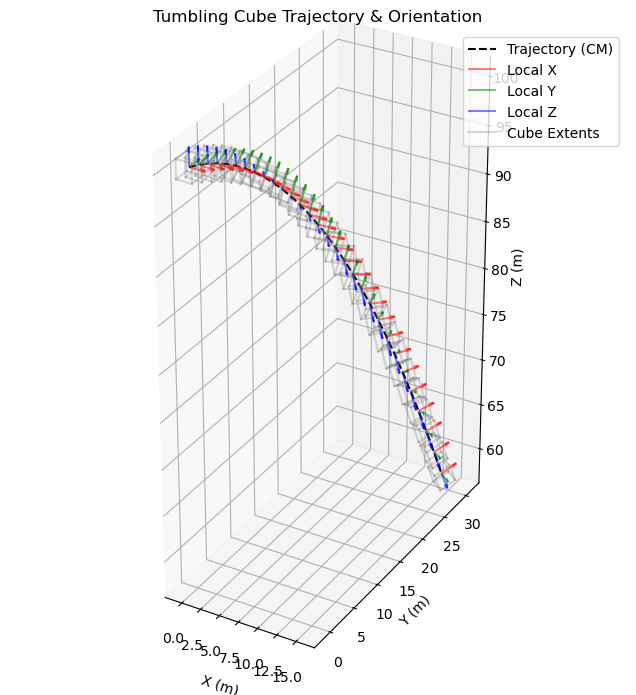

In [13]:
import matplotlib.pyplot as plt
import time

def _skew(w):
    """Skew-symmetric matrix s.t. _skew(w) @ v == w x v"""
    return np.array([
        [ 0,    -w[2],  w[1]],
        [ w[2],  0,    -w[0]],
        [-w[1],  w[0],  0   ]
    ])

# ---------------------------------------------------------------------------
# Integrator 1: Euler Angles (Z-Y-X convention)
# ---------------------------------------------------------------------------
def integrate_euler_angles(pos0, vel0, gravity, omega_body, dt, steps):
    pos, vel = pos0.copy(), vel0.copy()
    phi, theta, psi = 0.0, 0.0, 0.0
    p, q_ang, r = omega_body

    t0 = time.perf_counter()
    for _ in range(steps):
        vel += gravity * dt
        pos += vel * dt

        # Kinematic equations in Z-Y-X convention.
        # math.tan(theta) and 1/math.cos(theta) blow up at pitch = ±90° (gimbal lock).
        phi_dot   = p + (q_ang * math.sin(phi) + r * math.cos(phi)) * math.tan(theta)
        theta_dot = q_ang * math.cos(phi) - r * math.sin(phi)
        psi_dot   = (q_ang * math.sin(phi) + r * math.cos(phi)) / math.cos(theta)

        phi   += phi_dot   * dt
        theta += theta_dot * dt
        psi   += psi_dot   * dt
    elapsed = time.perf_counter() - t0

    return pos, (phi, theta, psi), elapsed

# ---------------------------------------------------------------------------
# Integrator 2: Quaternions
# ---------------------------------------------------------------------------
def integrate_quaternions(pos0, vel0, gravity, omega_body, dt, steps):
    pos, vel = pos0.copy(), vel0.copy()
    q = np.quaternion(1, 0, 0, 0)
    omega_q = np.quaternion(0, *omega_body)
    pos_hist, q_hist = [], []

    t0 = time.perf_counter()
    for i in range(steps):
        vel += gravity * dt
        pos += vel * dt

        q += 0.5 * q * omega_q * dt
        q = q.normalized()

        if i % 10 == 0:
            pos_hist.append(pos.copy())
            q_hist.append(q.copy())
    elapsed = time.perf_counter() - t0

    return pos, q, pos_hist, q_hist, elapsed

# ---------------------------------------------------------------------------
# Integrator 3: Rotation Matrices
# ---------------------------------------------------------------------------
def integrate_rotation_matrices(pos0, vel0, gravity, omega_body, dt, steps):
    pos, vel = pos0.copy(), vel0.copy()
    R = np.eye(3)
    Omega = _skew(omega_body)  # constant body-frame skew matrix

    t0 = time.perf_counter()
    for _ in range(steps):
        vel += gravity * dt
        pos += vel * dt

        R += (R @ Omega) * dt
        # Re-orthogonalize via SVD to prevent drift (6 constraints to maintain)
        U, _, Vt = np.linalg.svd(R)
        R = U @ Vt
    elapsed = time.perf_counter() - t0

    return pos, R, elapsed

# ---------------------------------------------------------------------------
# Orchestrator: compare all three methods
# ---------------------------------------------------------------------------
def demonstrate_cube_dynamics_comparison():
    print("=== Dynamics Comparison: Euler Angles vs Quaternions vs Rotation Matrices ===")
    print("Simulating a falling, tumbling cube under Newtonian gravity.\n")

    pos0    = np.array([0.0, 0.0, 100.0])
    vel0    = np.array([5.0, 10.0, 0.0])
    gravity = np.array([0.0, 0.0, -9.81])
    omega_body = np.array([1.0, 0.5, 0.2])
    dt, steps = 0.01, 300

    pos_e, (phi, theta, psi), t_euler = integrate_euler_angles(
        pos0, vel0, gravity, omega_body, dt, steps)
    pos_q, q, pos_hist, q_hist, t_quat = integrate_quaternions(
        pos0, vel0, gravity, omega_body, dt, steps)
    pos_r, R_final, t_rot = integrate_rotation_matrices(
        pos0, vel0, gravity, omega_body, dt, steps)

    print(f"Final Position: [X: {pos_q[0]:.2f}, Y: {pos_q[1]:.2f}, Z: {pos_q[2]:.2f}] m\n")

    # Convert each representation to a quaternion for apples-to-apples comparison.
    # Z-Y-X convention: compose yaw, then pitch, then roll.
    q_yaw   = np.quaternion(math.cos(psi/2),   0,               0,                math.sin(psi/2)  )
    q_pitch = np.quaternion(math.cos(theta/2), 0,               math.sin(theta/2),0                )
    q_roll  = np.quaternion(math.cos(phi/2),   math.sin(phi/2), 0,                0                )
    q_from_euler = q_yaw * q_pitch * q_roll

    q_from_rot = quaternion.from_rotation_matrix(R_final)
    # q and -q encode the same rotation (double cover of SO(3)).
    # from_rotation_matrix can return either sign; snap to the same hemisphere as q
    # so the difference metric is meaningful.
    if np.dot(quaternion.as_float_array(q), quaternion.as_float_array(q_from_rot)) < 0:
        q_from_rot = -q_from_rot

    print("--- Final Orientation (all expressed as quaternions) ---")
    print(f"  Quaternion integrator : {q}")
    print(f"  Euler angles          : {q_from_euler}")
    print(f"  Rotation matrix       : {q_from_rot}")
    diff_euler = abs((q - q_from_euler).norm())
    diff_rot   = abs((q - q_from_rot  ).norm())
    print(f"\n  |q_quat - q_euler| = {diff_euler:.2e}  (expected: small trig integration error)")
    print(f"  |q_quat - q_rot  | = {diff_rot:.2e}  (expected: small SVD re-ortho error)")

    print("\n--- Integration Loop Timing ({} steps) ---".format(steps))
    print(f"  Euler angles      : {t_euler*1e3:7.3f} ms")
    print(f"  Quaternions       : {t_quat *1e3:7.3f} ms")
    print(f"  Rotation matrices : {t_rot  *1e3:7.3f} ms")

    # -----------------------------------------------------------------------
    # Visualization (uses quaternion history from the quaternion integrator)
    # -----------------------------------------------------------------------
    print("\nGenerating 3D Visualization...")
    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_subplot(111, projection='3d')

    pos_arr = np.array(pos_hist)
    ax.plot(pos_arr[:, 0], pos_arr[:, 1], pos_arr[:, 2], 'k--', label='Trajectory (CM)')

    r = 1.0
    cube_vertices = np.array([
        [-r, -r, -r], [ r, -r, -r], [ r,  r, -r], [-r,  r, -r],
        [-r, -r,  r], [ r, -r,  r], [ r,  r,  r], [-r,  r,  r]
    ])
    cube_edges = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]

    axis_length = 2.0
    for i, (p, q_state) in enumerate(zip(pos_hist, q_hist)):
        R = quaternion.as_rotation_matrix(q_state)
        local_x, local_y, local_z = R[:, 0], R[:, 1], R[:, 2]

        ax.quiver(*p, *local_x, color='r', alpha=0.5, length=axis_length, normalize=True, label='Local X' if i==0 else "")
        ax.quiver(*p, *local_y, color='g', alpha=0.5, length=axis_length, normalize=True, label='Local Y' if i==0 else "")
        ax.quiver(*p, *local_z, color='b', alpha=0.5, length=axis_length, normalize=True, label='Local Z' if i==0 else "")

        verts = (R @ cube_vertices.T).T + p
        for edge in cube_edges:
            ax.plot(
                [verts[edge[0], 0], verts[edge[1], 0]],
                [verts[edge[0], 1], verts[edge[1], 1]],
                [verts[edge[0], 2], verts[edge[1], 2]],
                color='gray', alpha=0.3, linewidth=1.5,
                label='Cube Extents' if i==0 and edge==cube_edges[0] else ""
            )

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title('Tumbling Cube Trajectory & Orientation')
    ax.legend()
    try:
        ax.set_box_aspect((np.ptp(pos_arr[:, 0]), np.ptp(pos_arr[:, 1]), np.ptp(pos_arr[:, 2])))
    except AttributeError:
        pass

    plt.show()

demonstrate_cube_dynamics_comparison()
